# Mouse hypothalamic (MERFISH)

## importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scipy.io
import pickle

import warnings
warnings.filterwarnings('ignore')
import scipy.sparse as sp
import enclus

sc.set_figure_params(dpi=300,fontsize=10,dpi_save=300,facecolor='white',format='pdf')

## Data Integration

In [2]:
st_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_st_data.h5ad')
sc_data = sc.read('./datasets/ProcessedMERFISH_hypothalamic_sc_data.h5ad')
if isinstance(sc_data.X, sp.csr_matrix):
    sc_data.X = sc_data.X.toarray()
print(sc_data,st_data)

AnnData object with n_obs × n_vars = 30370 × 27998
    obs: 'cell_type', 'domain_id', 'source'
    var: 'Gene'
    uns: 'log1p' AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'cell_type', 'domain_id', 'source'
    uns: 'log1p'
    obsm: 'spatial'


In [ ]:
enclus_model = enclus.ENCLUS(spatial_data = st_data, sc_data = sc_data,
                    num_layers=3,
                    num_neurons=1024,
                    latent_dim=512,
                    k_nearest=8,
                    num_cov_genes=64,
                    cov_genes=[],
                    num_HVG=2048,
                    spatial_dist="pois",
                    sc_dist="nb",
                    spatial_coeff=1,  
                    sc_coeff=1,   
                    kl_coeff=0.05, 
                    n_clusters=6,
                    tau=0.1, 
                    gamma=0.1,
                    adaptive_weights=True,
                    early_stopping=True,
                    patience=20,
                    num_heads=10,
                    head_dim=128
                    )

enclus_model.train(training_steps=6000,
    batch_size=4096,
    verbose=16,
    init_lr=0.0005,
    decay_steps=4000)

enclus_model.impute_genes()


st_data.obsm['enclus_latent'] = enclus_model.spatial_data.obsm['enclus_latent']

st_data.obsm['imputation'] = enclus_model.spatial_data.obsm['imputation']

sc_data.obsm['enclus_latent'] = enclus_model.sc_data.obsm['enclus_latent']

sc_data shape and st_data shape: (30370, 2189) (64373, 154)
Initializing CVAE
Finished Initializing ENCLUS
Initializing cluster centers...


 | spatial_w: 3.62 sc_w: 8.65 cov_w: 8.41 kl_w: 0.60 cluster_w: 1.42:   6%|▌         | 273/4628 [59:03<15:42:10, 12.98s/it]


Early stopping triggered


Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENCLUS.spatial_data


In [4]:
# st_data.obsm['imputation']

In [35]:
# sc_data.write('./datasets/ENCLUS_hypo_sc.h5ad')
# st_data.write('./datasets/ENCLUS_hypo_st.h5ad')

## Evaluate the results with various scores
After integration,Visualize the data using UMAP according to their cell types and sources.

In [6]:
# sc_data = sc.read('./datasets/ENCLUS_hypo_sc.h5ad')
# st_data = sc.read('./datasets/ENCLUS_hypo_st.h5ad')
# sc_data,st_data

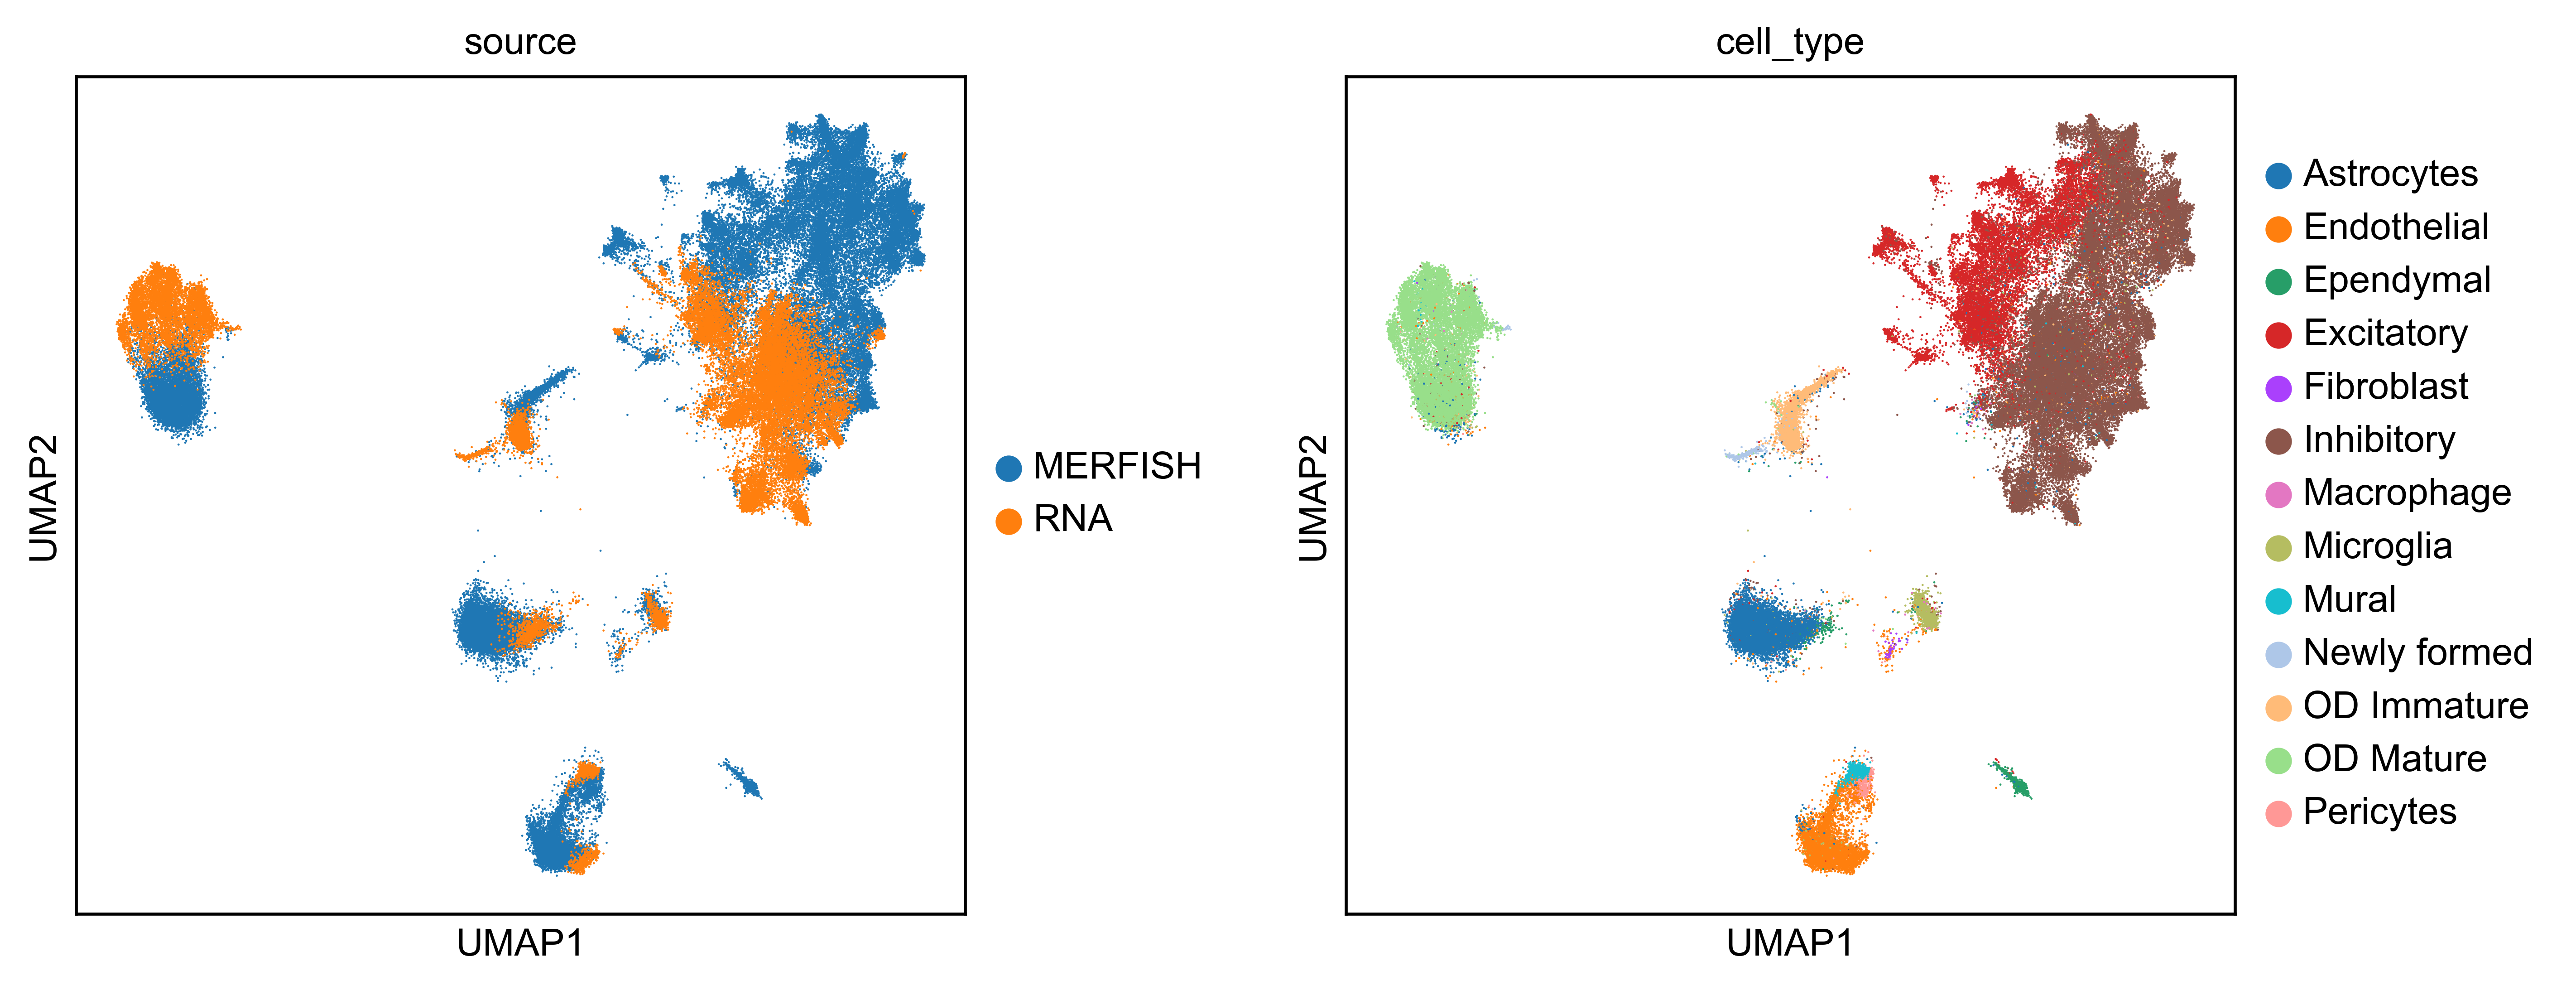

In [28]:
import anndata as ad
sc.settings.figdir = './Result/hypothalamic/'
use_rep = 'enclus_latent'
adata = ad.concat([st_data,sc_data], join='inner', merge='same')
sc.tl.pca(adata)
sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=22)
sc.tl.umap(adata,min_dist=0.1, n_components=2)
sc.pl.umap(adata, color=['source','cell_type'],save='enclus-integrated.pdf',wspace=0.3,legend_fontsize=10)

We evaluated the results by F1, ARI, NMI, Batch Entropy and Silhouette scores.

In [32]:
import enclus.metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score
adata1 = adata[adata.obs['domain_id']==0]
adata2 = adata[adata.obs['domain_id']==1]
y_test = enclus.metrics.label_transfer(adata2, adata1, label='cell_type', rep='X_umap')

f1 = f1_score(adata1.obs['cell_type'], y_test, average='weighted')
ARI = adjusted_rand_score(adata1.obs['cell_type'], y_test)
NMI = normalized_mutual_info_score(adata1.obs['cell_type'], y_test)
print('F1:', f1)
print('ARI:', ARI)
print('NMI:', NMI)
print('total score:',f1+ARI+NMI)
print('Batch Entropy:', enclus.metrics.batch_entropy_mixing_score(adata.obsm['X_umap'], adata.obs['domain_id']))
print('Silhouette:', enclus.metrics.silhouette(adata.obsm['X_umap'], adata.obs['cell_type']))

F1: 0.8644674623565449
ARI: 0.7796801267520229
NMI: 0.757568693254186
total score: 2.401716282362754
Batch Entropy: 0.19221229685557456
Silhouette: 0.6560687


## Methods comparison 

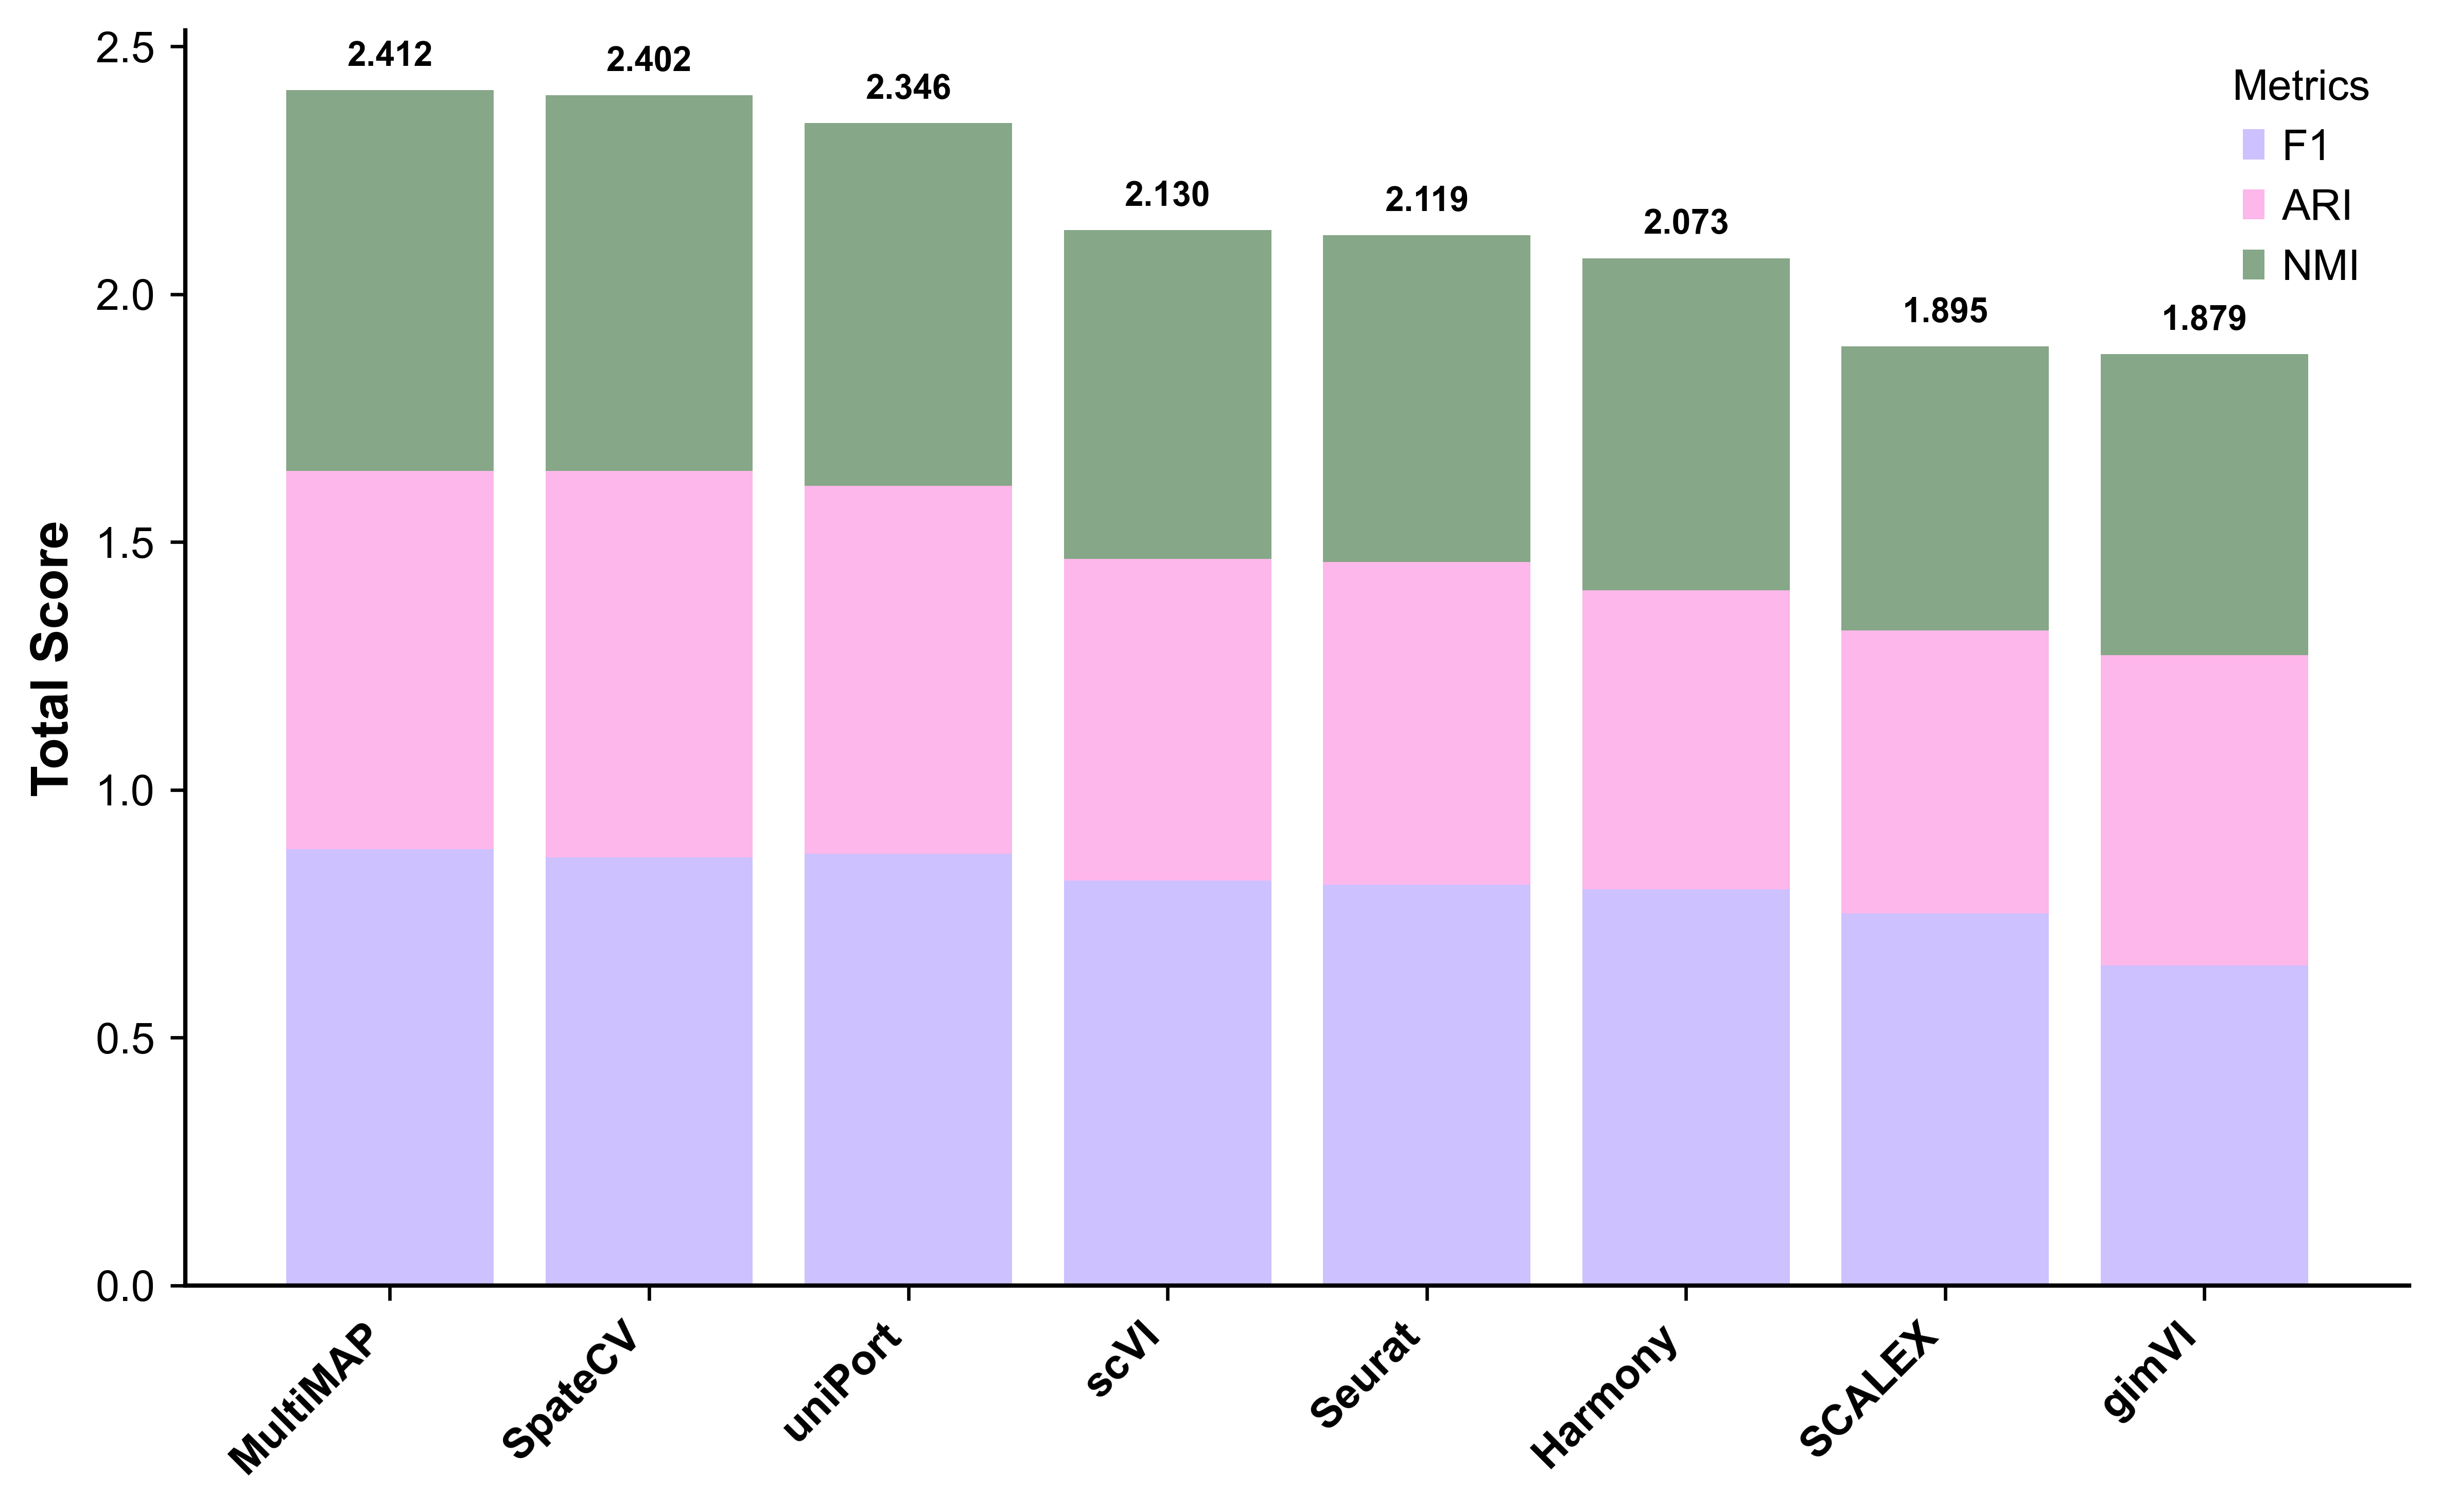

In [2]:
data = {
    "Harmony": [0.800, 0.603, 0.670],
    "Seurat": [0.809, 0.651, 0.659],
    "SCALEX": [0.751, 0.571, 0.573],
    "scVI": [0.817, 0.649, 0.664],
    "uniPort": [0.871, 0.743, 0.732],
    "gimVI": [0.646, 0.626, 0.607],
    "MultiMAP": [0.881, 0.763, 0.768],
    "SpateCV": [0.864, 0.780, 0.758],
}
metrics = [ "F1","ARI", "NMI"]
df = pd.DataFrame(data, index=metrics)

# Calculate the total score for each method and sort them by the total score
df.loc["Total Score"] = df.sum(axis=0)
df_sorted = df.T.sort_values(by="Total Score", ascending=False).drop(columns=["Total Score"])

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

bottom = np.zeros(len(df_sorted))
colors = ["#CDC1FF", "#FDB7EA", "#86A788"] 

for idx, metric in enumerate(metrics):
    ax.bar(df_sorted.index, df_sorted[metric], bottom=bottom, label=metric, color=colors[idx])
    bottom += df_sorted[metric]
    
for i, (method, row) in enumerate(df_sorted.iterrows()):
    total_score = row.sum()
    ax.text(i, total_score + 0.05, f'{total_score:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_ylabel("Total Score", fontsize=12, fontweight='bold')
ax.set_xticklabels(df_sorted.index, rotation=45, ha="right", fontsize=10, fontweight='bold')
ax.set_yticks(np.arange(0, max(bottom) + 0.2, 0.5))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.legend(title="Metrics", fontsize=10, title_fontsize=10, frameon=False, loc='upper right')
# ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.grid(None)
plt.tight_layout()
plt.savefig('./Result/hypothalamic/metrics.pdf')
plt.show()


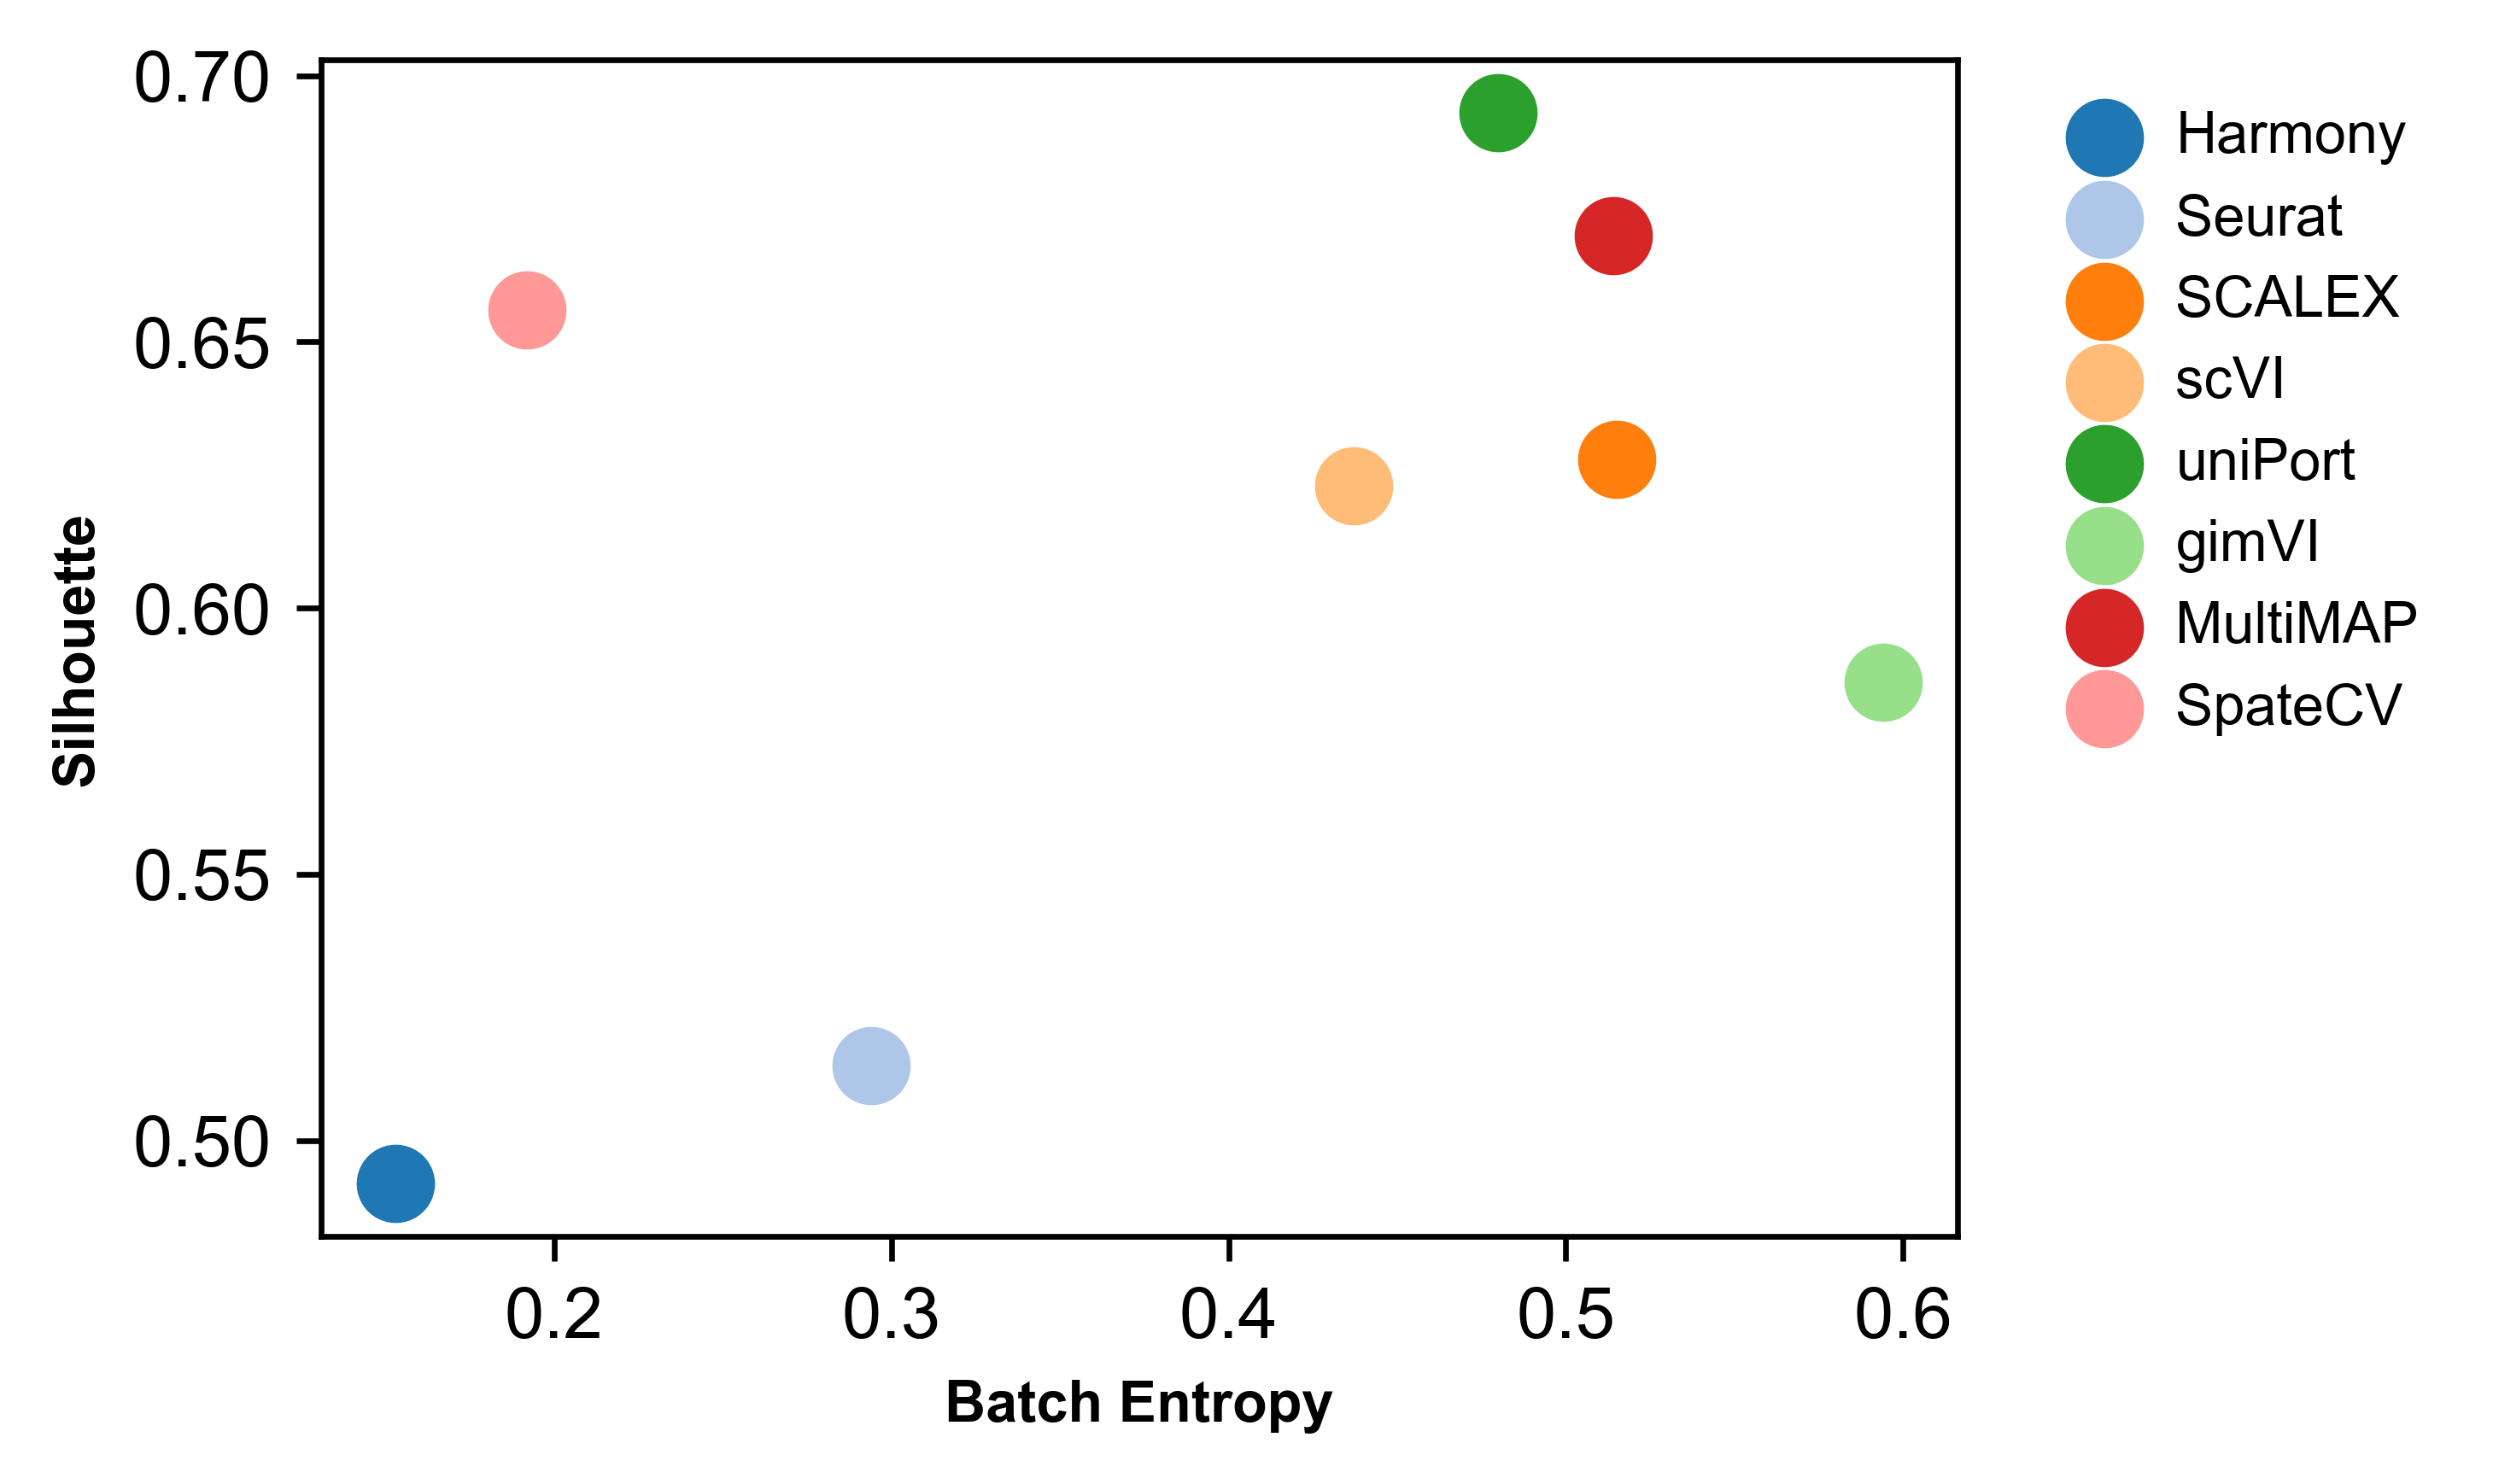

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

methods = ["Harmony", "Seurat", "SCALEX", "scVI", "uniPort", "gimVI", "MultiMAP", "SpateCV"]
metrics = ["Batch Entropy", "Silhouette"]
values = np.array([
    [0.153, 0.294, 0.515, 0.437, 0.480, 0.594, 0.514, 0.192],
    [0.492, 0.514, 0.628, 0.623, 0.693, 0.586, 0.670, 0.656]
])

df = pd.DataFrame(values, index=metrics, columns=methods)

fig, ax = plt.subplots(figsize=(5, 3), dpi=300)
cmap = plt.get_cmap("tab20")  
colors = [cmap(i) for i in range(len(methods))]

for i, method in enumerate(methods):
    ax.scatter(df.loc["Batch Entropy", method], df.loc["Silhouette", method], 
               label=method, color=colors[i], s=100)

ax.set_xlabel("Batch Entropy", fontsize=8, fontweight='bold')
ax.set_ylabel("Silhouette", fontsize=8, fontweight='bold')

ax.legend(loc="upper left", fontsize=8, frameon=False, handletextpad=1, bbox_to_anchor=(1.05, 1))
ax.grid(None)

plt.tight_layout()
plt.savefig('./Result/hypothalamic/batch_silh.pdf')
plt.show()


## Visualize sc and st latent

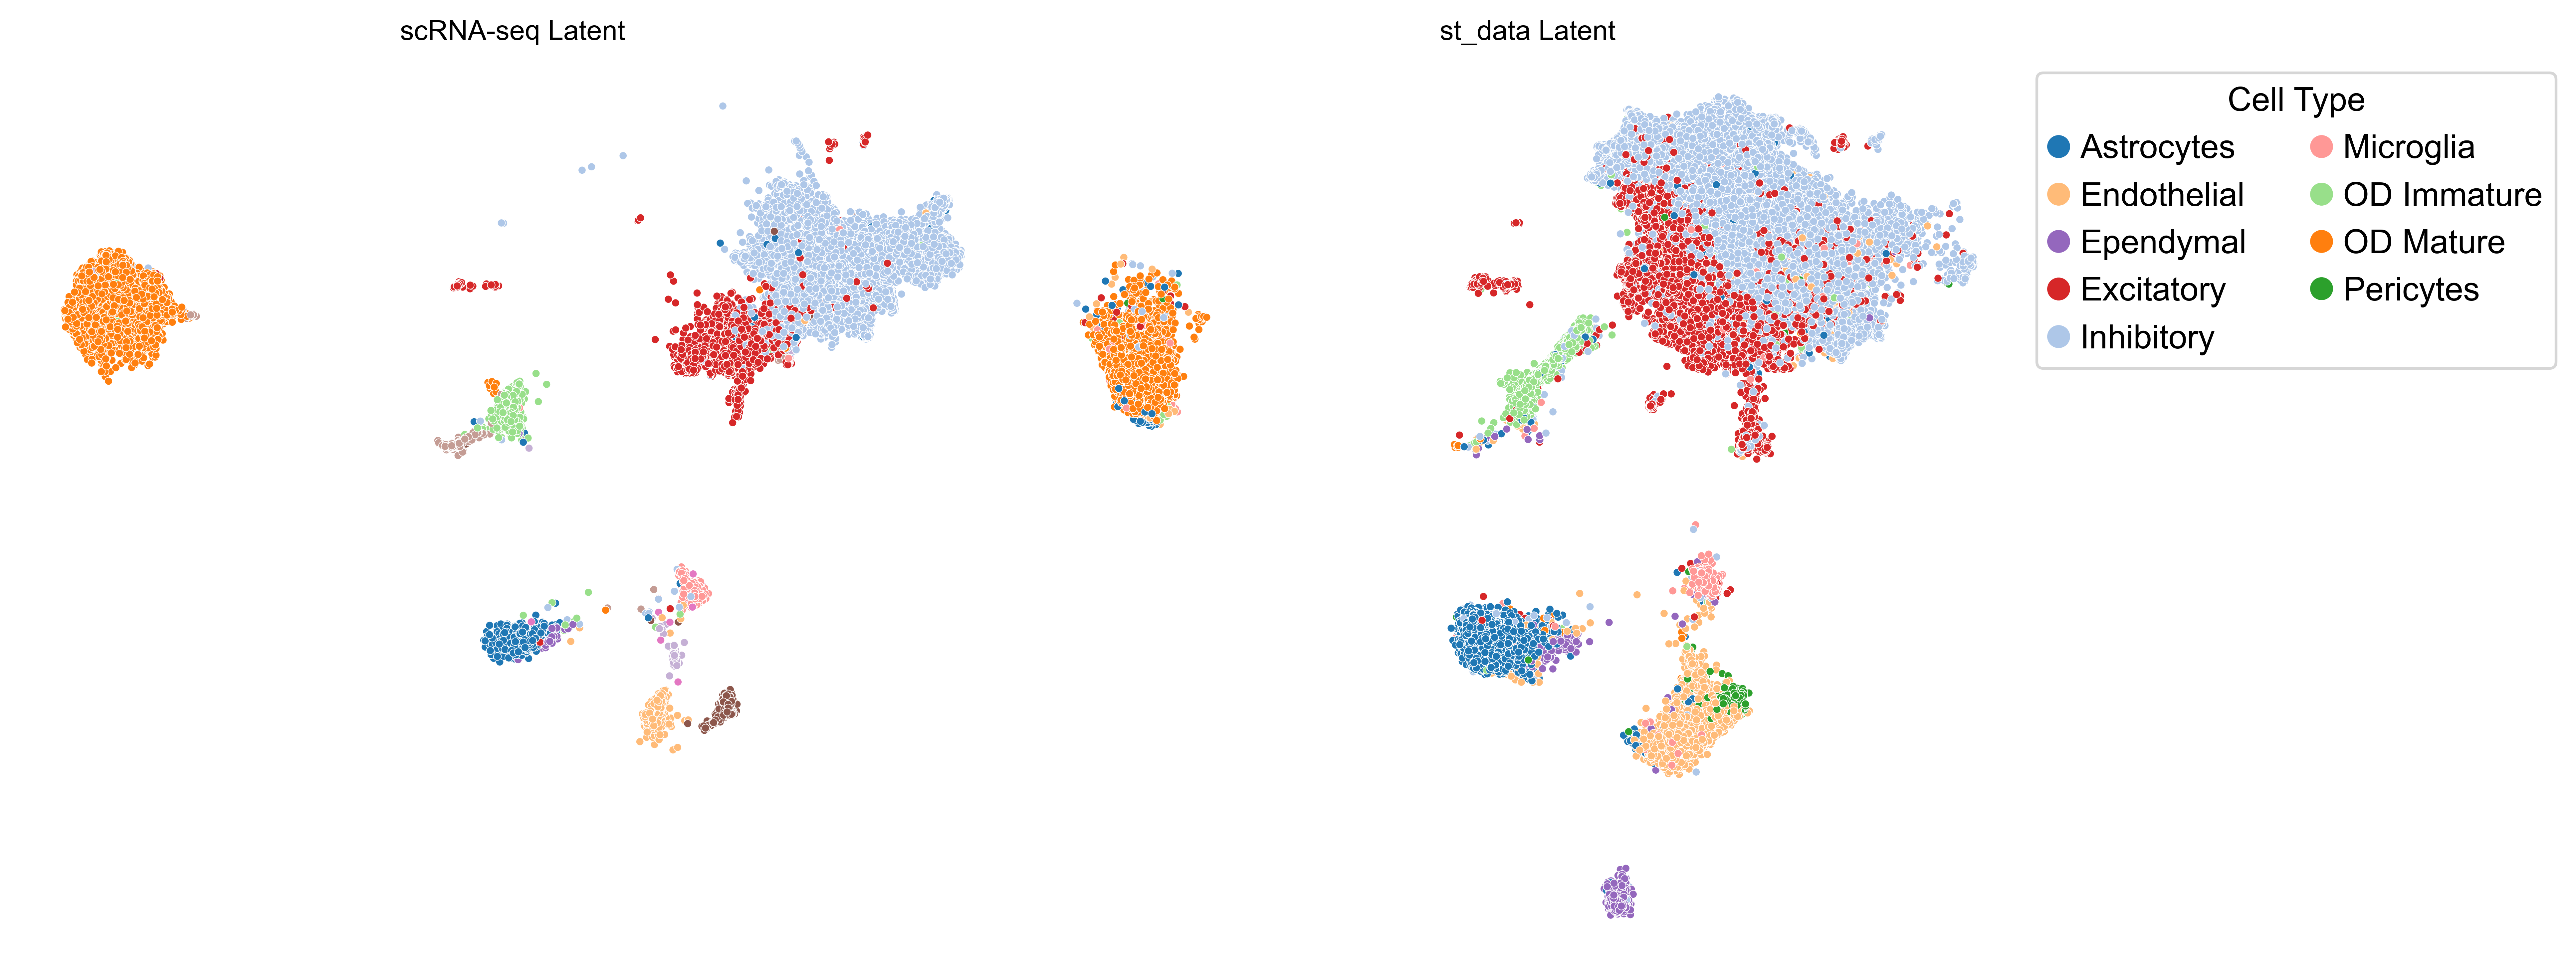

In [41]:

import umap.umap_ as umap
fit = umap.UMAP(
    n_neighbors = 15,
    min_dist = 0.1,
    n_components = 2,
)

latent_umap = fit.fit_transform(np.concatenate([st_data.obsm['enclus_latent'], sc_data.obsm['enclus_latent']], axis = 0))

st_data.obsm['latent_umap'] = latent_umap[:st_data.shape[0]]
sc_data.obsm['latent_umap'] = latent_umap[st_data.shape[0]:]

lim_arr = np.concatenate([st_data.obsm['latent_umap'], sc_data.obsm['latent_umap']], axis = 0)


delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta

color_dict = {'Astrocytes': '#1f77b4',
 'Inhibitory': '#aec7e8',
 'OD Mature': '#ff7f0e',
 'Endothelial': '#ffbb78',
 'Pericytes': '#2ca02c',
 'OD Immature': '#98df8a',
 'Excitatory': '#d62728',
 'Microglia': '#ff9896',
 'Ependymal': '#9467bd',
 'Fibroblast': '#c5b0d5',
 'Mural': '#8c564b',
 'Newly formed': '#c49c94',
 'Macrophage': '#e377c2',
 }
#13
labelnames = ['Astrocytes', 'Inhibitory', 'OD Mature', 'Endothelial', 'Pericytes', 'OD Immature', 'Excitatory', 'Microglia', 'Ependymal',
            'Fibroblast','Mural','Newly formed','Macrophage']

fig = plt.figure(figsize = (13,5),dpi=300)
plt.subplot(121)
sns.scatterplot(x = sc_data.obsm['latent_umap'][:, 0],
                y = sc_data.obsm['latent_umap'][:, 1], hue = sc_data.obs['cell_type'], s = 8, palette = color_dict,
                legend = False)
plt.title("scRNA-seq Latent")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.axis('off')

plt.subplot(122)
sns.scatterplot(x = st_data.obsm['latent_umap'][:, 0],
                y = st_data.obsm['latent_umap'][:, 1],  hue = st_data.obs['cell_type'], s = 8, palette = color_dict, legend = True)


legend = plt.legend(title = 'Cell Type', prop={'size': 12}, fontsize = '12',  markerscale = 3, ncol = 2, bbox_to_anchor = (1, 1))#, loc = 'lower left')
plt.setp(legend.get_title(),fontsize='12')
plt.title("st_data Latent")
plt.axis('off')
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.savefig('./Result/hypothalamic/latent.pdf')
plt.show()

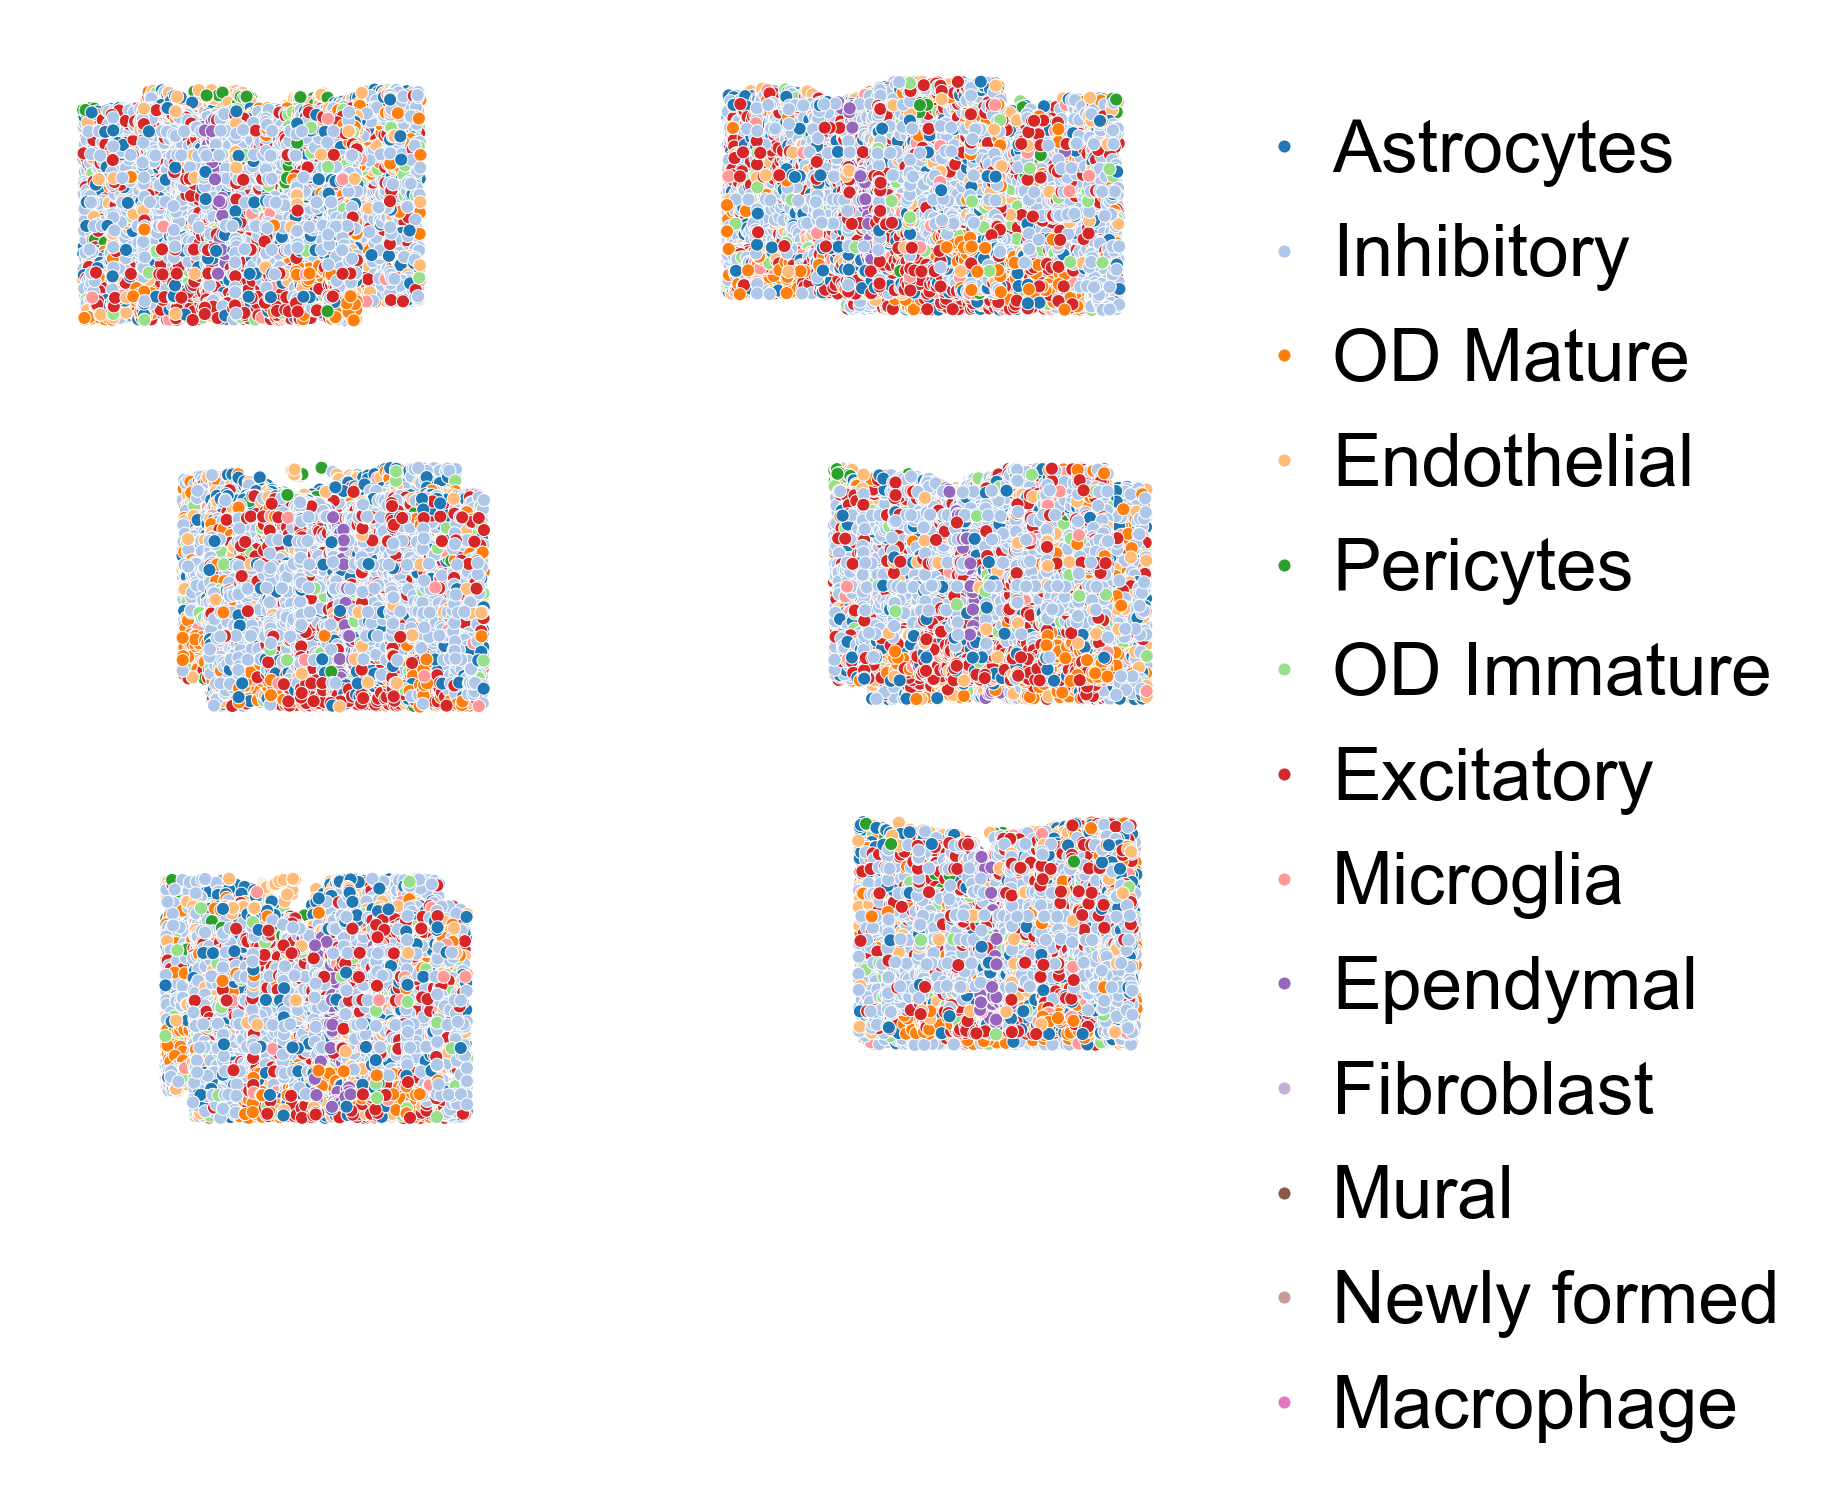

In [ ]:
color_dict = {'Astrocytes': '#1f77b4',
 'Inhibitory': '#aec7e8',
 'OD Mature': '#ff7f0e',
 'Endothelial': '#ffbb78',
 'Pericytes': '#2ca02c',
 'OD Immature': '#98df8a',
 'Excitatory': '#d62728',
 'Microglia': '#ff9896',
 'Ependymal': '#9467bd',
 'Fibroblast': '#c5b0d5',
 'Mural': '#8c564b',
 'Newly formed': '#c49c94',
 'Macrophage': '#e377c2',
 }
st_data.obs['x'] = st_data.obsm['spatial'][:,0]
st_data.obs['y'] = st_data.obsm['spatial'][:,1]
sns.set_context('paper',font_scale=2) 
plt.subplots(figsize=(5,5),dpi=150)
sns.scatterplot(data=st_data.obs, x="x", y="y", hue="cell_type",hue_order=labelnames,s=10,palette=color_dict)
plt.legend(bbox_to_anchor=(1.0,0.98), loc="upper left",framealpha=0,markerscale=1.5)
plt.gca().invert_yaxis()
plt.axis('off')
plt.show()

## Data preprocessing

In [8]:
df = pd.read_csv('./datasets/hypothalamic/Moffitt_and_Bambah-Mukku_et_al_merfish_all_cells.csv')

# Extract the rows where 'Animal_ID' is equal to 1
filtered_df = df[df['Animal_ID'] == 1]
filtered_df = filtered_df[filtered_df['Cell_class'] != 'Ambiguous']
# Merge the rows 'OD Mature 1' and 'OD Mature 2' and name it 'OD Mature'
filtered_df.loc[filtered_df['Cell_class'].isin(['OD Mature 1', 'OD Mature 2','OD Mature 3','OD Mature 4']), 'Cell_class'] = 'OD Mature'
filtered_df.loc[filtered_df['Cell_class'].isin(['OD Immature 1', 'OD Immature 2']), 'Cell_class'] = 'OD Immature'
filtered_df.loc[filtered_df['Cell_class'].isin(['Endothelial 1', 'Endothelial 2','Endothelial 3']), 'Cell_class'] = 'Endothelial'
filtered_df.loc[filtered_df['Cell_class'].isin(['Astrocyte']), 'Cell_class'] = 'Astrocytes'

print(filtered_df['Cell_class'].unique())

expression_columns = df.columns[filtered_df.columns.get_loc('Ace2'):]
# Check which genes (columns) contain NaN
nan_genes = filtered_df[expression_columns].isna().any()
nan_gene = nan_genes[nan_genes].index[0]

# Columns to be deleted, including genes containing NaN and the 'Blank' column
columns_to_drop = [nan_gene] + ['Blank_1', 'Blank_2', 'Blank_3', 'Blank_4', 'Blank_5']


filtered_df = filtered_df.drop(columns=columns_to_drop)

# Select the required columns
# 1. Cell_ID and Cell_class will be used for obs
# 2. Centroid_X and Centroid_Y will be used for spatial
# 3. From Ace2 to the last column are gene expression data
expression_columns = filtered_df.columns[filtered_df.columns.get_loc('Ace2'):]

gene_names = expression_columns.tolist()

# Create AnnData object
# st_data.obs contains Cell_ID and Cell_class
# st_data.spatial contains Centroid_X and Centroid_Y
# st_data.X contains gene expression data from Ace2 to the last row
st_data = sc.AnnData(
    X=filtered_df[expression_columns].values,  
    obs=filtered_df[['Cell_ID', 'Cell_class']].set_index('Cell_ID'),  # Cell_ID 和 Cell_class
    obsm={'spatial': filtered_df[['Centroid_X', 'Centroid_Y']].values}  
)

st_data.var_names = gene_names

st_data.obs.rename(columns={'Cell_class': 'cell_type'}, inplace=True)


print(st_data)

# st_data.write('./datasets/hypothalamic/MERFISH_hypothalamic_st_data.h5ad')

['Astrocytes' 'Inhibitory' 'OD Mature' 'Endothelial' 'Pericytes'
 'OD Immature' 'Excitatory' 'Microglia' 'Ependymal']
AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'cell_type'
    obsm: 'spatial'


In [3]:
import pandas as pd
import scipy.io
import scanpy as sc

# Read the gene expression matrix (.mtx file)
matrix = scipy.io.mmread('./datasets/hypothalamic/GSE113576_matrix.mtx').tocsc().T

# Read the barcodes and genes files
barcodes = pd.read_csv('./datasets/hypothalamic/GSE113576_barcodes.tsv', header=None, sep='\t')
genes = pd.read_csv('./datasets/hypothalamic/GSE113576_genes.tsv', header=None, sep='\t')

sc_data = sc.AnnData(X=matrix)

# Set the index of obs to barcodes
sc_data.obs = pd.DataFrame(index=barcodes[0].values)

sc_data.var['Gene'] = genes[1].values
sc_data.var_names = genes[1].values

# Read the cell type annotation file (Excel file)
cell_type_df = pd.read_excel('./datasets/hypothalamic/NIHMS1024025-supplement-Table_S1.xlsx')
cell_type_dict = cell_type_df[['Cell_ID', 'Cell_class']]

# Merge cell type information into the obs of the AnnData object
sc_data.obs = sc_data.obs.merge(cell_type_dict, left_index=True, right_on='Cell_ID', how='left')

sc_data.obs['Cell_class'] = sc_data.obs['Cell_class'].replace({
    'Immature oligodendrocyte': 'OD Immature',
    'Mature oligodendrocyte': 'OD Mature',
    'Newly formed oligodendrocyte':'Newly formed'
})

# Delete rows with values 'Ambiguous' and 'Unstable' in Cell_class
sc_data = sc_data[~sc_data.obs['Cell_class'].isin(['Ambiguous', 'Unstable'])]
sc_data.obs.set_index('Cell_ID', inplace=True)
sc_data.obs.rename(columns={'Cell_class': 'cell_type'}, inplace=True)
print(sc_data.obs['cell_type'].unique())

print(sc_data)
# sc_data.write('./datasets/hypothalamic/MERFISH_hypothalamic_sc_data.h5ad')

['Fibroblast' 'Excitatory' 'Inhibitory' 'OD Mature' 'Endothelial'
 'OD Immature' 'Microglia' 'Mural' 'Newly formed' 'Astrocytes'
 'Macrophage' 'Ependymal']
AnnData object with n_obs × n_vars = 30370 × 27998
    obs: 'cell_type'
    var: 'Gene'


In [2]:
adata_merfish = sc.read('./datasets/hypothalamic/MERFISH_hypothalamic_st_data.h5ad')
adata_rna = sc.read('./datasets/hypothalamic/MERFISH_hypothalamic_sc_data.h5ad')
adata_merfish,adata_rna

(AnnData object with n_obs × n_vars = 64373 × 155
     obs: 'cell_type'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 30370 × 27998
     obs: 'cell_type'
     var: 'Gene')

In [3]:
adata_merfish.obs['domain_id'] = 0
adata_merfish.obs['domain_id'] = adata_merfish.obs['domain_id'].astype('category')
adata_merfish.obs['source'] = 'MERFISH'

adata_rna.obs['domain_id'] = 1
adata_rna.obs['domain_id'] = adata_rna.obs['domain_id'].astype('category')
adata_rna.obs['source'] = 'RNA'

print(adata_rna.obs)
print(adata_merfish.obs)

                     cell_type domain_id source
Cell_ID                                        
AAACCTGAGATGTGGC-1  Fibroblast         1    RNA
AAACCTGCACACAGAG-1  Excitatory         1    RNA
AAACCTGCACTACAGT-1  Inhibitory         1    RNA
AAACCTGTCAGGATCT-1  Excitatory         1    RNA
AAACCTGTCGCACTCT-1   OD Mature         1    RNA
...                        ...       ...    ...
TTTGGTTGTTATCACG-6  Inhibitory         1    RNA
TTTGGTTGTTATTCTC-6  Inhibitory         1    RNA
TTTGTCAGTTCCGTCT-6  Inhibitory         1    RNA
TTTGTCATCGTGGGAA-6  Inhibitory         1    RNA
TTTGTCATCTTTACAC-6  Excitatory         1    RNA

[30370 rows x 3 columns]
                                        cell_type domain_id   source
Cell_ID                                                             
6749ccb4-2ed1-4029-968f-820a287f43c8   Astrocytes         0  MERFISH
6cac74bd-4ea7-4701-8701-42563cc65eb8   Inhibitory         0  MERFISH
9f29bd57-16a5-4b26-b9f5-37598809da9e   Inhibitory         0  MERFISH
d7eb4

In [4]:
adata_rna = adata_rna[:, ~adata_rna.var_names.duplicated()]
adata_cm = adata_merfish.concatenate(adata_rna, join='inner', batch_key='domain_id')
print(adata_cm.obs)

                                         cell_type domain_id   source
Cell_ID                                                              
6749ccb4-2ed1-4029-968f-820a287f43c8-0  Astrocytes         0  MERFISH
6cac74bd-4ea7-4701-8701-42563cc65eb8-0  Inhibitory         0  MERFISH
9f29bd57-16a5-4b26-b9f5-37598809da9e-0  Inhibitory         0  MERFISH
d7eb4e0b-276e-47e3-a55c-0b033180a2fe-0  Inhibitory         0  MERFISH
54434f3a-eba9-4aec-af35-c9d317ffa1d5-0  Inhibitory         0  MERFISH
...                                            ...       ...      ...
TTTGGTTGTTATCACG-6-1                    Inhibitory         1      RNA
TTTGGTTGTTATTCTC-6-1                    Inhibitory         1      RNA
TTTGTCAGTTCCGTCT-6-1                    Inhibitory         1      RNA
TTTGTCATCGTGGGAA-6-1                    Inhibitory         1      RNA
TTTGTCATCTTTACAC-6-1                    Excitatory         1      RNA

[94743 rows x 3 columns]


In [5]:
import enclus.metrics
sc.pp.normalize_total(adata_cm)
sc.pp.log1p(adata_cm)
sc.pp.highly_variable_genes(adata_cm, n_top_genes=2000, batch_key='domain_id', inplace=False, subset=True)
enclus.metrics.batch_scale(adata_cm)
# adata_cm.write('./datasets/MERFISH_hypothalamic_cm_data.h5ad')

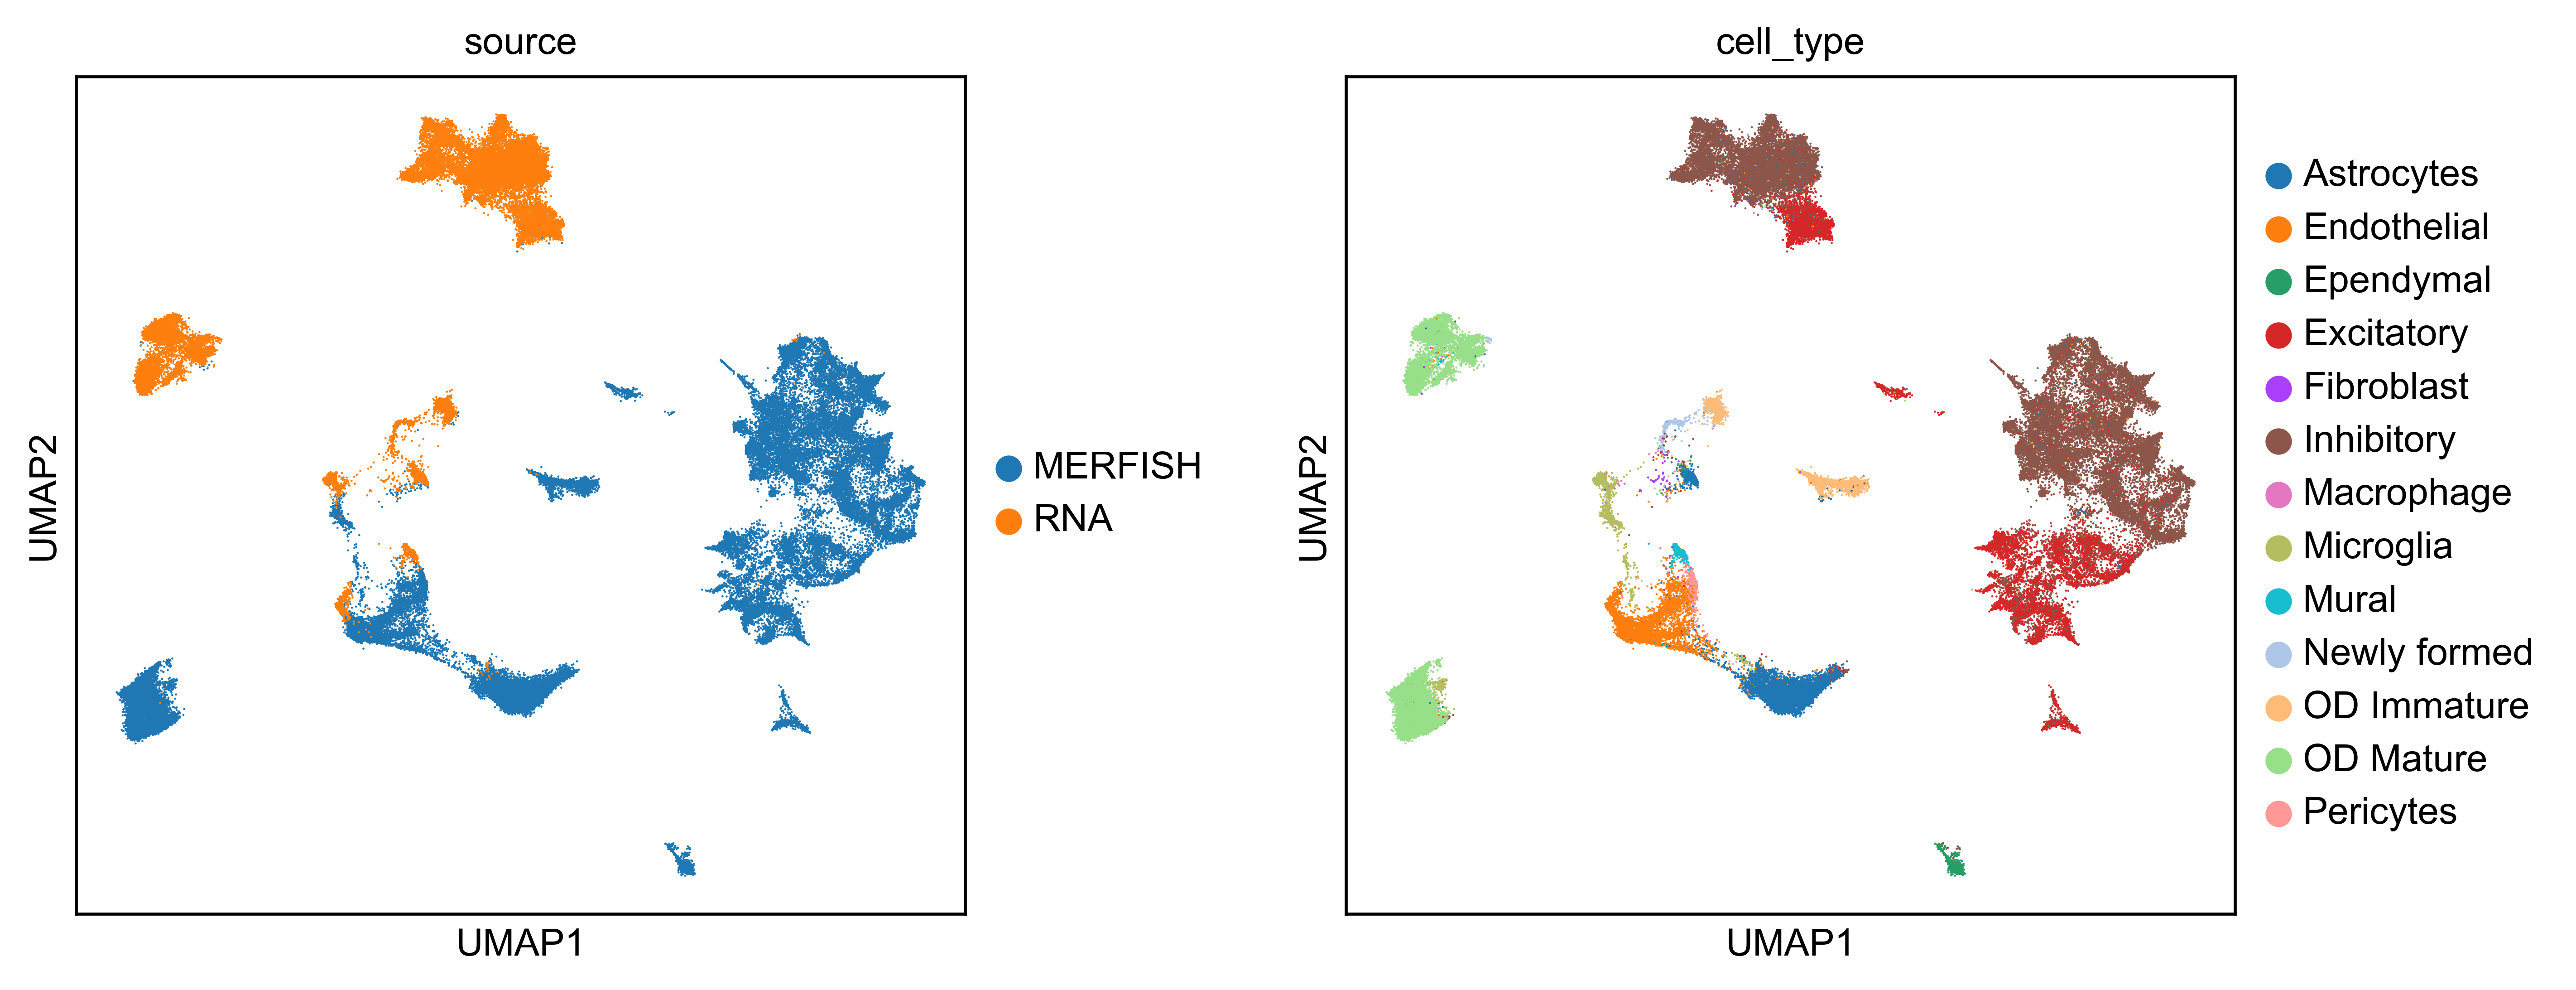

In [7]:
# adata_cm = sc.read('./datasets/MERFISH_hypothalamic_cm_data.h5ad')
sc.settings.figdir = './Result/hypothalamic/'
adata_cm_copy = adata_cm.copy()
sc.pp.pca(adata_cm_copy)
sc.pp.neighbors(adata_cm_copy)
sc.tl.umap(adata_cm_copy, min_dist=0.1)
sc.pl.umap(adata_cm_copy, color=['source', 'cell_type'],save='unintegrate.pdf',wspace=0.3,legend_fontsize=10)

Save the preprocessed data for integration and online prediction

In [5]:
# import enclus.metrics
# st_data = sc.read('./datasets/hypothalamic/MERFISH_hypothalamic_st_data.h5ad')
# sc_data = sc.read('./datasets/hypothalamic/MERFISH_hypothalamic_sc_data.h5ad')

# sc_data.obs_names_make_unique()
# st_data.obs_names_make_unique()

# sc_data.var_names_make_unique()
# sc_data.var_names_make_unique()

# st_data.obs['domain_id'] = 0
# st_data.obs['domain_id'] = st_data.obs['domain_id'].astype('category')
# st_data.obs['source'] = 'MERFISH'

# sc_data.obs['domain_id'] = 1
# sc_data.obs['domain_id'] = sc_data.obs['domain_id'].astype('category')
# sc_data.obs['source'] = 'RNA'

# sc.pp.normalize_total(st_data)
# sc.pp.log1p(st_data)
# sc.pp.highly_variable_genes(st_data, n_top_genes=2000, inplace=False, subset=True)
# enclus.metrics.batch_scale(st_data)

# sc.pp.normalize_total(sc_data)
# sc.pp.log1p(sc_data)
# sc.pp.highly_variable_genes(sc_data, n_top_genes=2000, inplace=False, subset=True)
# enclus.metrics.batch_scale(sc_data)

# print(sc_data,st_data)
# st_data.write_h5ad('./datasets/ProcessedMERFISH_hypothalamic_st_data.h5ad')
# sc_data.write_h5ad('./datasets/ProcessedMERFISH_hypothalamic_sc_data.h5ad')

AnnData object with n_obs × n_vars = 30370 × 27998
    obs: 'cell_type', 'domain_id', 'source'
    var: 'Gene'
    uns: 'log1p' AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'cell_type', 'domain_id', 'source'
    uns: 'log1p'
    obsm: 'spatial'
